## **Transition from Aggregated Analysis to Predictive Modelling**

In the earlier stages of this project, the analysis was based on aggregated NHS GP appointment data, where each observation represented monthly activity across the healthcare system. This made it possible to explore the overall scale of missed appointments (Did Not Attend – DNA), identify broader trends in demand, and estimate the financial impact on the NHS.

However, while this type of data is useful for understanding the problem at a system level, it does not allow for prediction at the level of individual patients. Since each row represents a summary rather than a specific appointment, it lacks the detail required to model patient behaviour.

To address this, this section uses the Kaggle Medical Appointment No-Show dataset, which contains over 110,000 individual appointment records. Unlike the NHS dataset, each row here represents a single patient appointment and includes demographic, behavioural, and clinical variables. This makes it suitable for building predictive models.

An important link between the earlier analysis and this section is the role of waiting time. In Section 1, longer waiting times were associated with higher rates of missed appointments.


In [138]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joniarroba/noshowappointments")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'noshowappointments' dataset.
Path to dataset files: /kaggle/input/noshowappointments


In [139]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [140]:
#import libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

df= pd.read_csv('/content/drive/MyDrive/KaggleV2-May-2016.csv')
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n:", df.dtypes)


Shape: (110527, 14)

Columns: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

Data types:
: PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object


In [141]:
#checking missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [142]:
#understanding the target variable
print(df['No-show'].value_counts())
print(df['No-show'].value_counts(normalize=True))

No-show
No     88208
Yes    22319
Name: count, dtype: int64
No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64


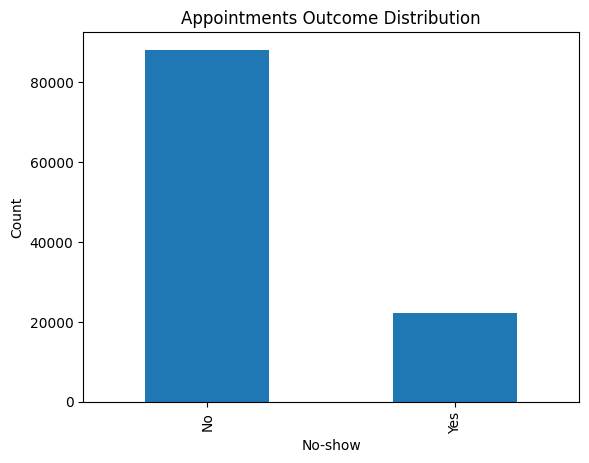

In [143]:
#target variable distribution
df['No-show'].value_counts().plot(kind='bar')

plt.title("Appointments Outcome Distribution")
plt.xlabel("No-show")
plt.ylabel("Count")
plt.show()

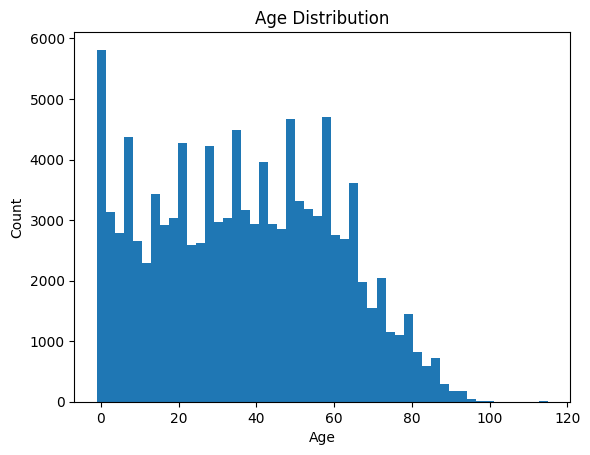

In [144]:
#age distribution
plt.hist(df['Age'], bins= 50)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

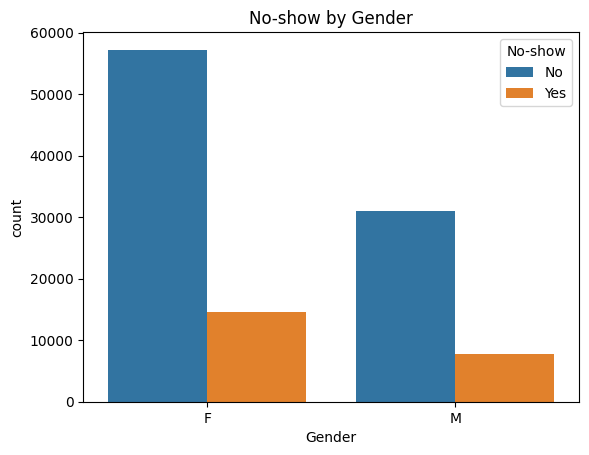

In [145]:
#no-show by gender
import seaborn as sns

sns.countplot(x= 'Gender', hue= 'No-show', data= df)
plt.title("No-show by Gender")
plt.show()

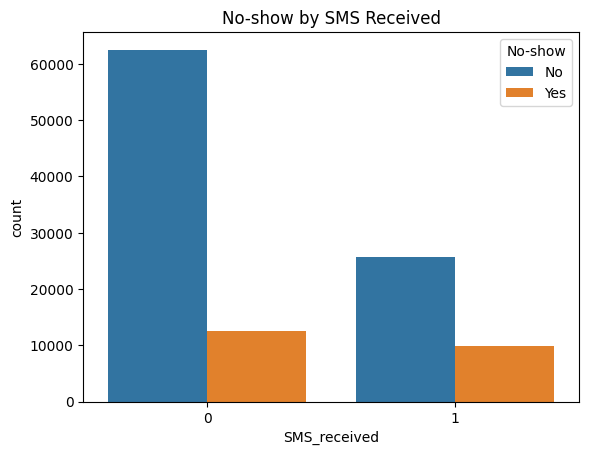

In [146]:
#no-show by SMS-received
sns.countplot(x= 'SMS_received', hue= "No-show", data = df)
plt.title("No-show by SMS Received")
plt.show()

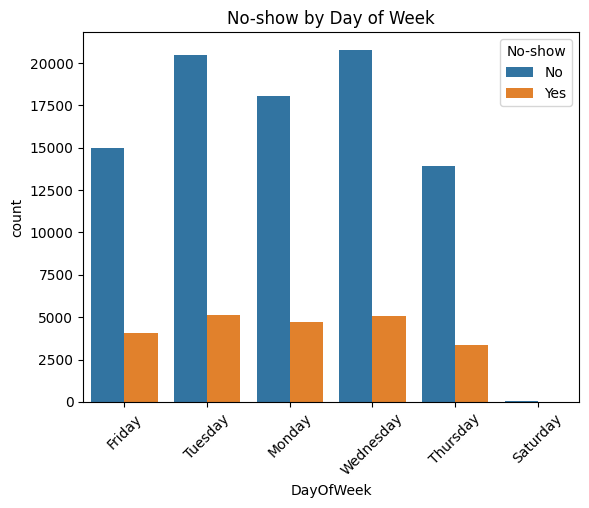

In [147]:
#no-show by day-of-week
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

df['DayOfWeek'] = df['AppointmentDay'].dt.day_name()

sns.countplot(x='DayOfWeek', hue='No-show', data=df)

plt.xticks(rotation=45)
plt.title("No-show by Day of Week")
plt.show()

In [148]:
#removing negative age rows
df= df[df['Age']>=0]
print(df['Age'].min())

0


In [149]:
#change to datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [150]:
#creating waitingtime feature
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
print(df['WaitingDays'].describe())

count    110526.000000
mean          9.183794
std          15.255034
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: WaitingDays, dtype: float64


In [151]:
#removing negative waiting time rows
df= df[df['WaitingDays']>=0]
print(df['WaitingDays'].min())

0


In [152]:
#encoding target variable
df['No-show'] = df['No-show'].map({'No': 0, 'Yes': 1})
print(df['No-show'].value_counts())

No-show
0    51437
1    20522
Name: count, dtype: int64


In [153]:
#checking the Gender variable
print(df['Gender'].unique())

['F' 'M']


In [154]:
#encoding the Gender variable
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})
print(df['Gender'].value_counts())
print(df['Gender'].isnull().sum())

Gender
0    48070
1    23889
Name: count, dtype: int64
0


In [155]:
#dropping unnecessary columns
df = df.drop(columns=[
    'PatientId',
    'AppointmentID',
    'Neighbourhood',
    'ScheduledDay',
    'AppointmentDay'
])

In [156]:
#checking the new modified dataset
print(df.head())
print(df.shape)

    Gender  Age  Scholarship  Hipertension  Diabetes  Alcoholism  Handcap  \
5        0   76            0             1         0           0        0   
6        0   23            0             0         0           0        0   
7        0   39            0             0         0           0        0   
9        0   19            0             0         0           0        0   
10       0   30            0             0         0           0        0   

    SMS_received  No-show DayOfWeek  WaitingDays  
5              0        0    Friday            1  
6              0        1    Friday            1  
7              0        1    Friday            1  
9              0        0    Friday            1  
10             0        0    Friday            1  
(71959, 11)


In [157]:
#one-hot encoding of day-of-week variable
df = pd.get_dummies(df, columns=['DayOfWeek'], drop_first=True)
print(df.head())
print(df.shape)

    Gender  Age  Scholarship  Hipertension  Diabetes  Alcoholism  Handcap  \
5        0   76            0             1         0           0        0   
6        0   23            0             0         0           0        0   
7        0   39            0             0         0           0        0   
9        0   19            0             0         0           0        0   
10       0   30            0             0         0           0        0   

    SMS_received  No-show  WaitingDays  DayOfWeek_Monday  DayOfWeek_Saturday  \
5              0        0            1             False               False   
6              0        1            1             False               False   
7              0        1            1             False               False   
9              0        0            1             False               False   
10             0        0            1             False               False   

    DayOfWeek_Thursday  DayOfWeek_Tuesday  DayOfWeek_Wed

In [158]:
#Block 3- Logistic Regression

X= df.drop('No-show', axis=1)
y= df['No-show']

In [159]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

In [160]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [161]:
y_pred= model.predict(X_test)

In [162]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5519038354641468
              precision    recall  f1-score   support

           0       0.76      0.55      0.64     10301
           1       0.33      0.56      0.42      4091

    accuracy                           0.55     14392
   macro avg       0.55      0.56      0.53     14392
weighted avg       0.64      0.55      0.57     14392



In [163]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf= RandomForestClassifier(random_state= 42)

rf.fit(X_train, y_train)
y_pred_rf= rf.predict(X_test)

In [164]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6572401334074486
              precision    recall  f1-score   support

           0       0.73      0.82      0.77     10301
           1       0.35      0.24      0.28      4091

    accuracy                           0.66     14392
   macro avg       0.54      0.53      0.53     14392
weighted avg       0.62      0.66      0.64     14392



In [165]:
#what causes no-show
import pandas as pd

feature_importance= pd.Series(
    rf.feature_importances_,
    index= X.columns
).sort_values(ascending= False)
print(feature_importance)

Age                    0.539690
WaitingDays            0.352593
Gender                 0.019194
SMS_received           0.012907
Hipertension           0.011469
DayOfWeek_Tuesday      0.008727
DayOfWeek_Wednesday    0.008534
Diabetes               0.008185
Handcap                0.008153
Scholarship            0.008145
DayOfWeek_Thursday     0.008045
DayOfWeek_Monday       0.007409
Alcoholism             0.006604
DayOfWeek_Saturday     0.000345
dtype: float64
